In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%precision 3
%matplotlib inline

In [4]:
df = pd.read_csv('../data/ch4_scores400.csv')
scores = np.array(df['score'])
scores[:10]

array([76, 55, 80, 80, 74, 61, 81, 76, 23, 80])

In [ ]:
# 무작위 추출 - 복원 추출(동일한 표본이 여러 차례 선택될 수 있는 방법)

In [9]:
 np.random.choice([1, 2, 3], 3)

array([2, 1, 1])

In [10]:
# 무작위 추출 - 비복원 추출(동일한 표본이 한 번만 선택되는 방법)

In [12]:
 np.random.choice([1, 2, 3], 3, replace=False)

array([1, 2, 3])

In [13]:
# 시드를 0으로 하는 무작위 추출은 매번 동일한 결과 (시드가 1로 바뀌면 다른 무작위 값 나옴)

In [15]:
np.random.seed(0)
np.random.choice([1, 2, 3], 3)

array([1, 2, 1])

In [20]:
# 표본크기 20으로 복원추출 후, 표본 평균 계산 (모평균(실제 평균)은 69.530이므로 꽤 괜찮은 추측)

In [21]:
np.random.seed(0)
sample = np.random.choice(scores, 20)

sample.mean()

70.400

In [25]:
# 무작위 추측은 실행 시마다 결과가 달라지므로, 표본평균도 매번 달라짐
# (나오는 표본 평균이 실제 모평균과 비슷할 수도 있지만, 다를 수도 있음)

In [26]:
for i in range(5):
    sample = np.random.choice(scores, 20)
    print(f'{i+1}번째 무작위 추출로 얻은 표본평균', sample.mean())

1번째 무작위 추출로 얻은 표본평균 70.7
2번째 무작위 추출로 얻은 표본평균 71.9
3번째 무작위 추출로 얻은 표본평균 71.25
4번째 무작위 추출로 얻은 표본평균 67.4
5번째 무작위 추출로 얻은 표본평균 67.7


In [27]:
# 파이썬으로 불공정한 주사위의 확률분포를 구하는 실험

In [57]:
dice = [1, 2, 3, 4, 5, 6]
prob = [1/21, 2/21, 3/21, 4/21, 5/21, 6/21]

In [62]:
np.random.choice(dice, p=prob)

np.int64(1)

In [70]:
num_trial = 100
sample = np.random.choice(dice, num_trial, p=prob)
sample

array([4, 6, 3, 5, 6, 5, 6, 6, 6, 5, 6, 6, 4, 2, 4, 3, 4, 2, 5, 4, 6, 6,
       5, 3, 5, 6, 4, 5, 3, 4, 4, 3, 5, 4, 4, 5, 6, 4, 6, 6, 2, 3, 4, 2,
       4, 6, 5, 5, 5, 3, 4, 5, 6, 5, 3, 1, 5, 1, 4, 5, 6, 2, 4, 1, 4, 5,
       3, 3, 2, 5, 5, 5, 6, 1, 5, 5, 5, 6, 1, 5, 6, 5, 4, 6, 2, 4, 5, 5,
       2, 3, 4, 5, 6, 5, 2, 6, 6, 5, 6, 5])

In [78]:
# 불공정한 주사위의 확률분포를 통해 도수분포표 그리기

In [79]:
freq, _ = np.histogram(sample, bins=6, range=(1, 7))
pd.DataFrame({'frequency': freq,
              'relative frequency': freq / num_trial},
             index = pd.Index(np.arange(1, 7), name='dice'))

,frequency,relative frequency
dice,,
1,5,0.05
2,9,0.09
3,11,0.11
4,20,0.20
5,31,0.31
6,24,0.24


In [ ]:
# 불공정한 주사위의 확률분포를 통해 히스토그램 그리기

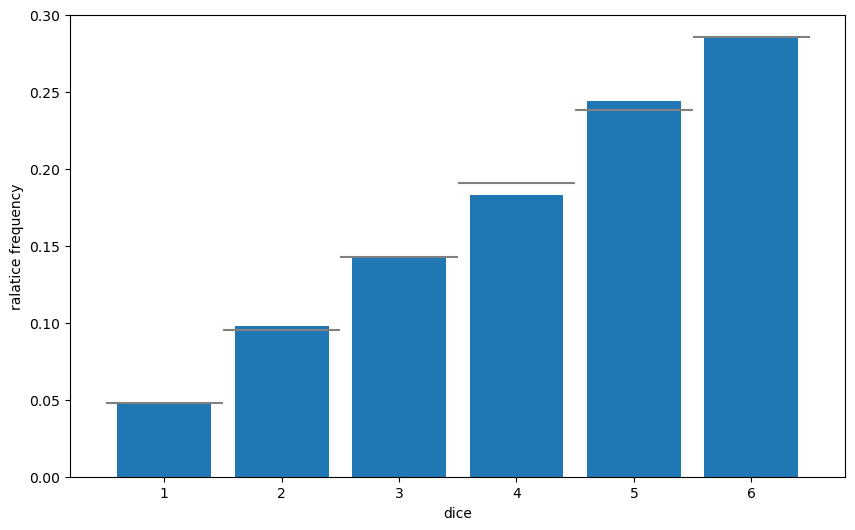

In [86]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.hist(sample, bins=6, range=(1, 7), density=True, rwidth=0.8)
ax.hlines(prob, np.arange(1, 7), np.arange(2, 8), colors='gray')
ax.set_xticks(np.linspace(1.5, 6.5, 6))
ax.set_xticklabels(np.arange(1, 7))
ax.set_xlabel('dice')
ax.set_ylabel('ralatice frequency')

plt.show()

In [84]:
# 불공정한 주사위를 10000번 시행했을 때의 히스토그램: 실제의 확률분포에 가까워짐

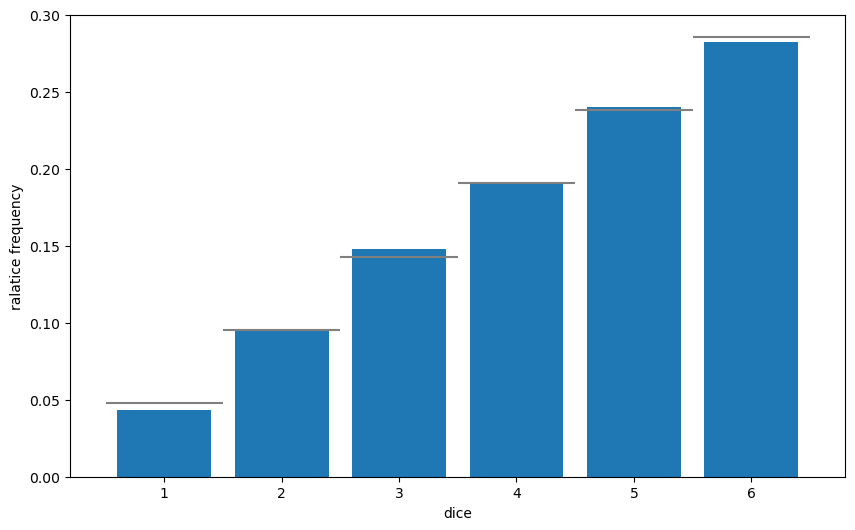

In [87]:
num_trial = 10000
sample = np.random.choice(dice, size=num_trial, p=prob)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.hist(sample, bins=6, range=(1, 7), density=True, rwidth=0.8)
ax.hlines(prob, np.arange(1, 7), np.arange(2, 8), colors='gray')
ax.set_xticks(np.linspace(1.5, 6.5, 6))
ax.set_xticklabels(np.arange(1, 7))
ax.set_xlabel('dice')
ax.set_ylabel('ralatice frequency')

plt.show()

In [88]:
# 계급폭을 1점으로 하는 히스토그램 (전교생의 시험점수가 어떻게 분포되어 있는지 알기 위함)

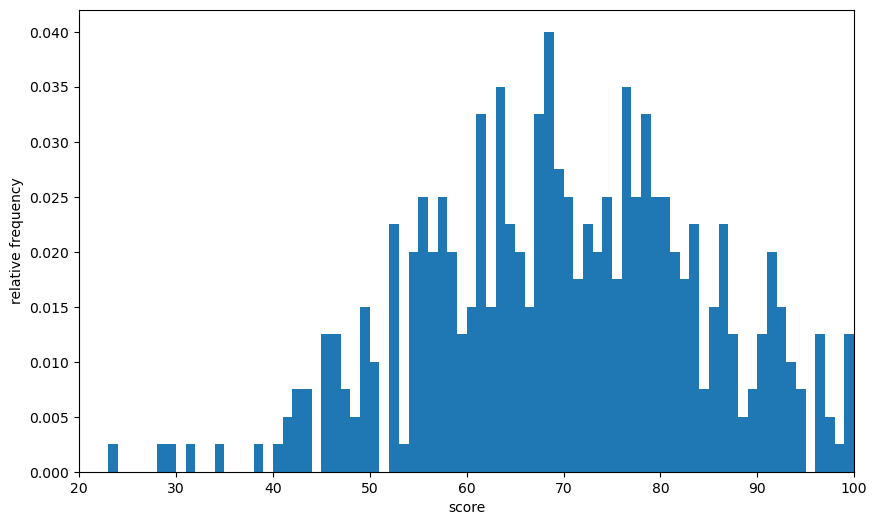

In [89]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.hist(scores, bins=100, range=(0, 100), density=True)
ax.set_xlim(20, 100)
ax.set_ylim(0, 0.042)
ax.set_xlabel('score')
ax.set_ylabel('relative frequency')

plt.show()

In [94]:
# 위의 히스토그램(무작위가 아닌 실제값)에서의 무작위 추출 한개
# 무작위 추출은 확률분포를 따르는 확률변수의 시행

In [95]:
np.random.choice(scores)

np.int64(59)

In [103]:
# 무작위 추출의 시행 횟수를 늘리면 표본 데이터의 상대도수는 실제의 확률분표에 근사 !!

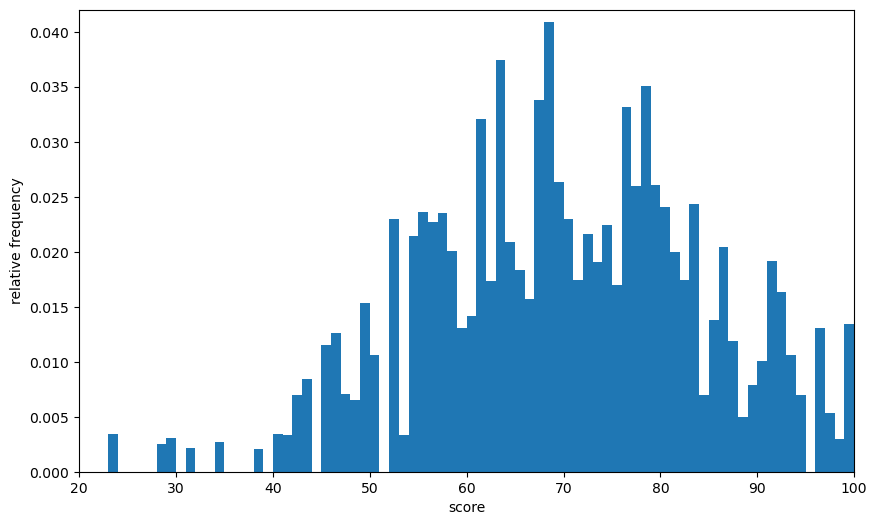

In [96]:
sample = np.random.choice(scores, 10000)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.hist(sample, bins=100, range=(0, 100), density=True)
ax.set_xlim(20, 100)
ax.set_ylim(0, 0.042)
ax.set_xlabel('score')
ax.set_ylabel('relative frequency')

plt.show()

In [ ]:
# 표본평균
# 표본 하나하나가 확률변수이므로, 표본들의 평균인 표본평균도 역시 확률변수

In [102]:
# 표본 크기가 20인 표본을 추출하여 표본평균을 계산하는 작업 10000번 수행
# => 표본 평균은 산포도 그 자체이므로, 모평균(가운데 세로선)을 중심으로 분포
# => 무작위 추출에 의한 표본 평균으로 모평균 추측 가능

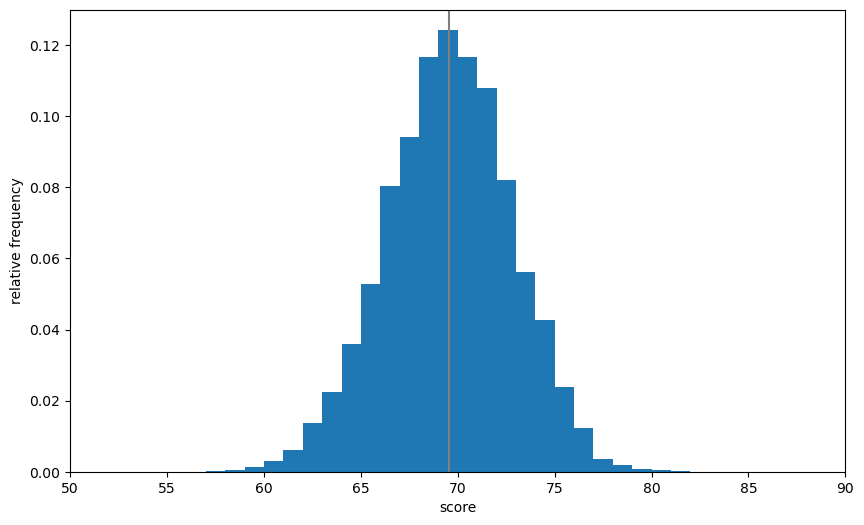

In [101]:
sample_means = [np.random.choice(scores, 20).mean()
                for _ in range(10000)]
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.hist(sample_means, bins=100, range=(0, 100), density=True)
ax.vlines(np.mean(scores), 0, 1, 'gray')
ax.set_xlim(50, 90)
ax.set_ylim(0, 0.13)
ax.set_xlabel('score')
ax.set_ylabel('relative frequency')

plt.show()